In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score, recall_score, f1_score
from sklearn.tree import DecisionTreeClassifier

In [2]:
df=pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [4]:
df["Insulin"].median()

30.5

In [5]:
df["Insulin"]==0

0       True
1       True
2       True
3      False
4      False
       ...  
763    False
764     True
765    False
766     True
767     True
Name: Insulin, Length: 768, dtype: bool

In [6]:
import numpy as np

df["Insulin"] = df["Insulin"].replace(0,30.5)

df["Insulin"]==0


0      False
1      False
2      False
3      False
4      False
       ...  
763    False
764    False
765    False
766    False
767    False
Name: Insulin, Length: 768, dtype: bool

In [7]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,30.5,33.6,0.627,50,1
1,1,85,66,29,30.5,26.6,0.351,31,0
2,8,183,64,0,30.5,23.3,0.672,32,1
3,1,89,66,23,94.0,28.1,0.167,21,0
4,0,137,40,35,168.0,43.1,2.288,33,1


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(3), int64(6)
memory usage: 54.1 KB


In [9]:
df.shape

(768, 9)

In [10]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

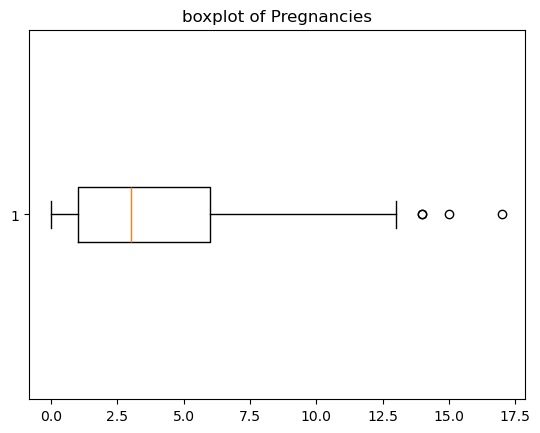

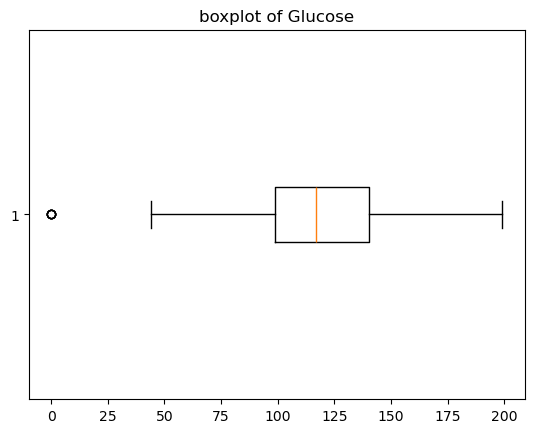

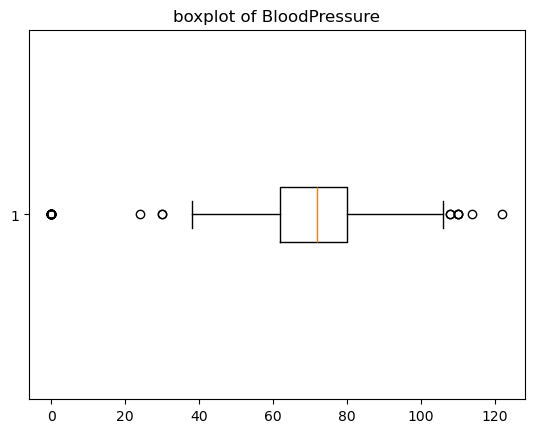

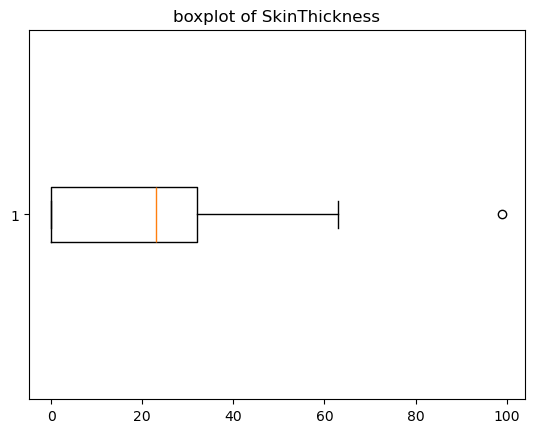

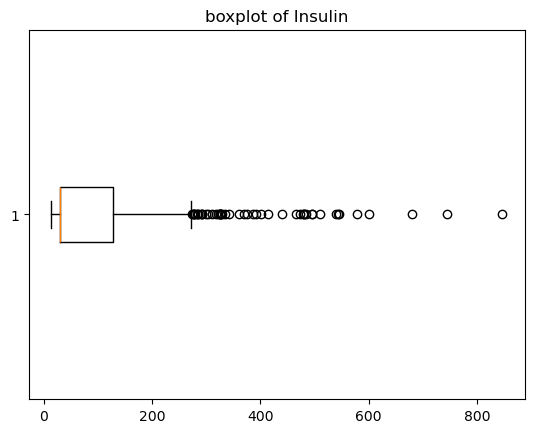

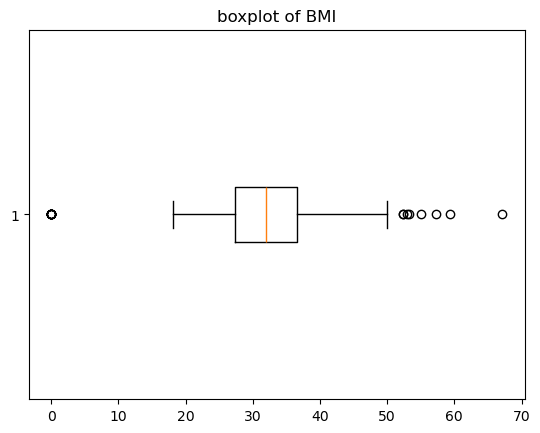

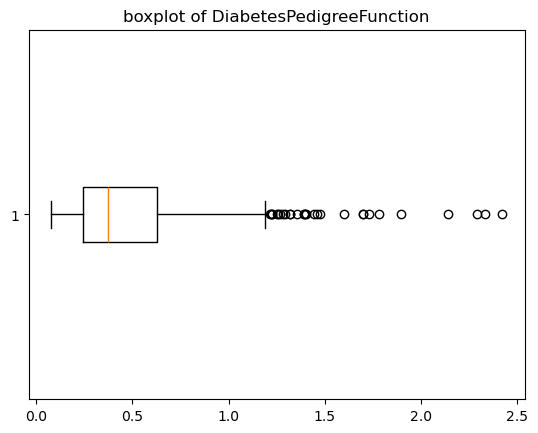

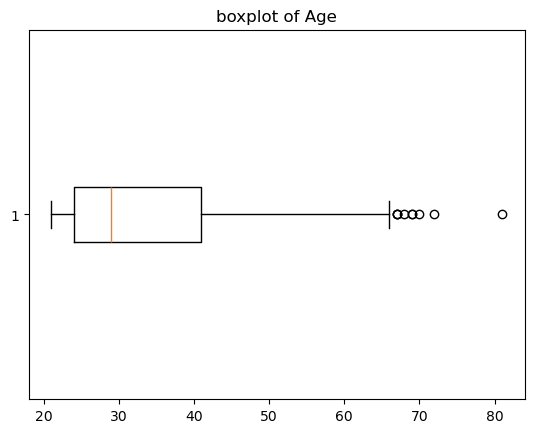

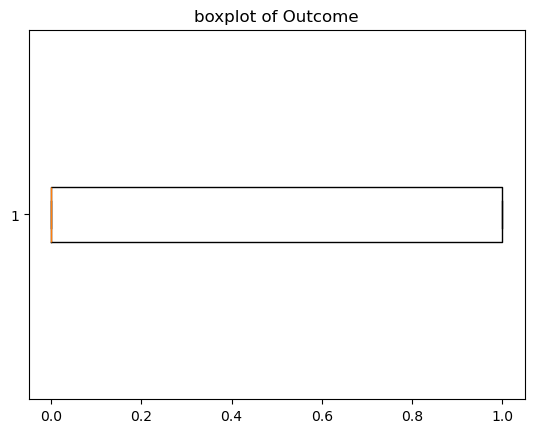

In [11]:
#boxplots
for i in df.columns:
    plt.boxplot(df[i],vert=False)
    plt.title(f"boxplot of {i}")
    plt.show()

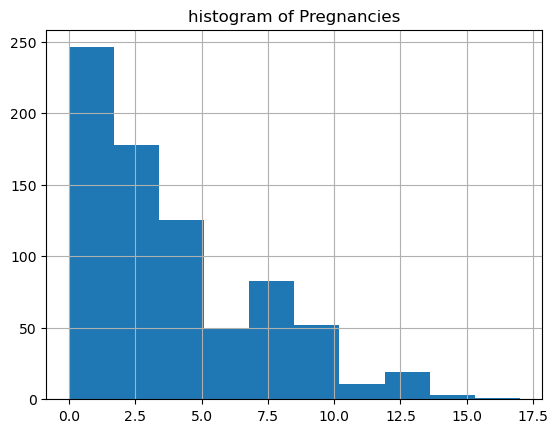

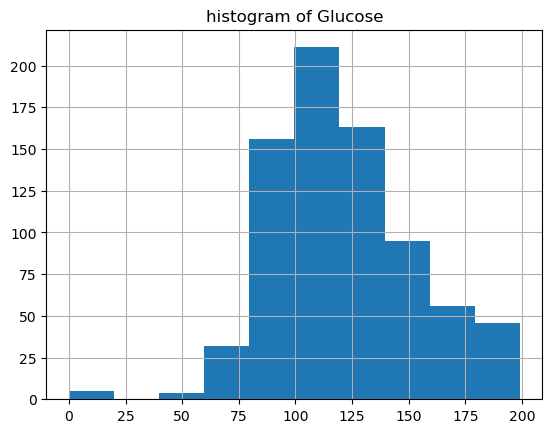

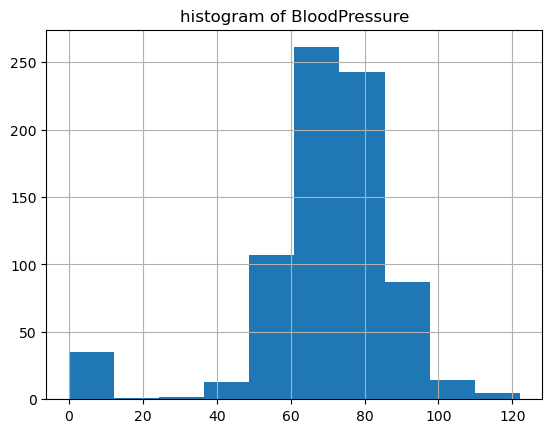

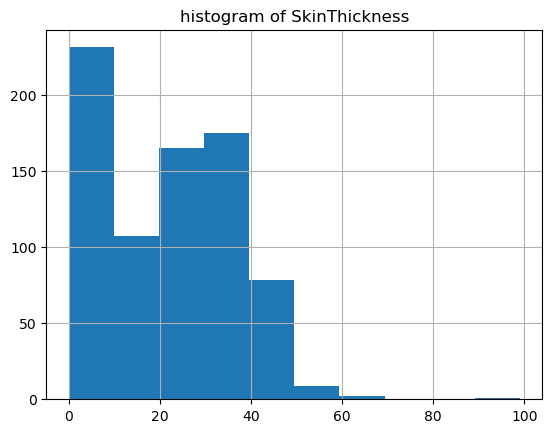

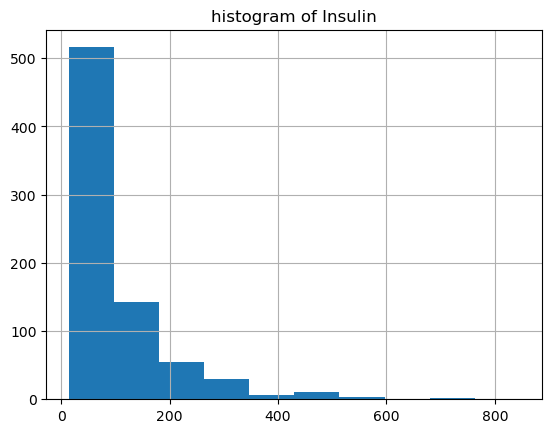

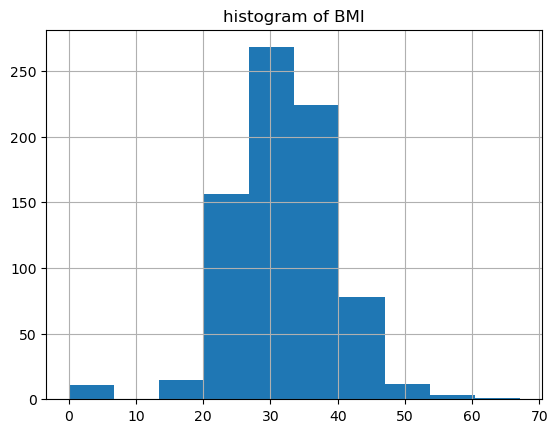

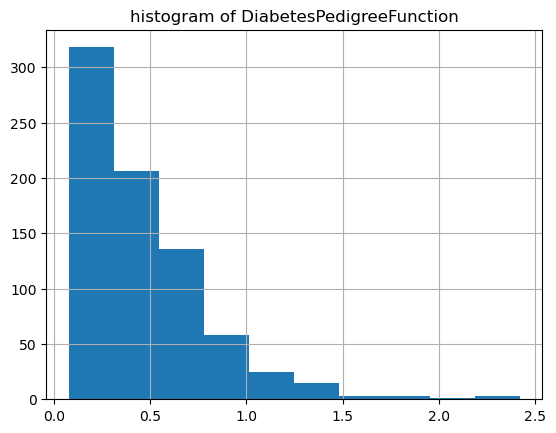

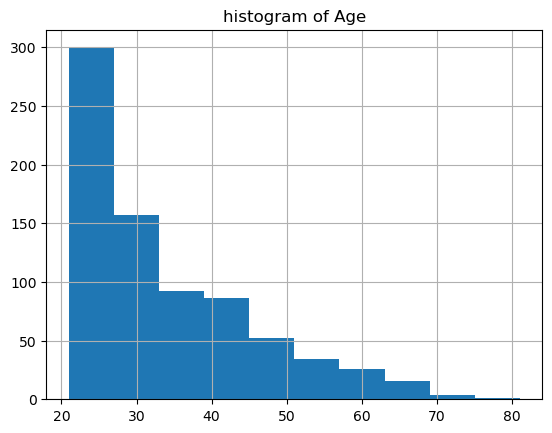

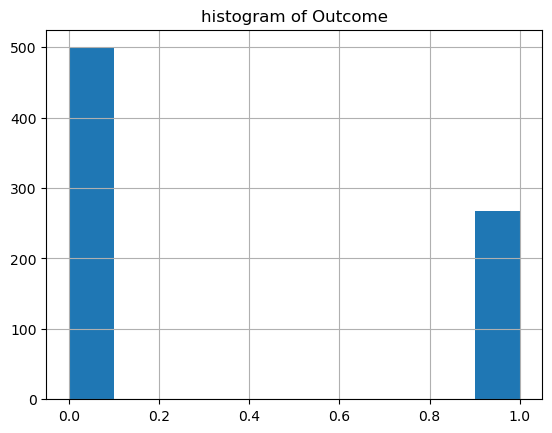

In [12]:
#histograms
for i in df.columns:
    df[i].hist()
    plt.title(f"histogram of {i}")
    plt.show()

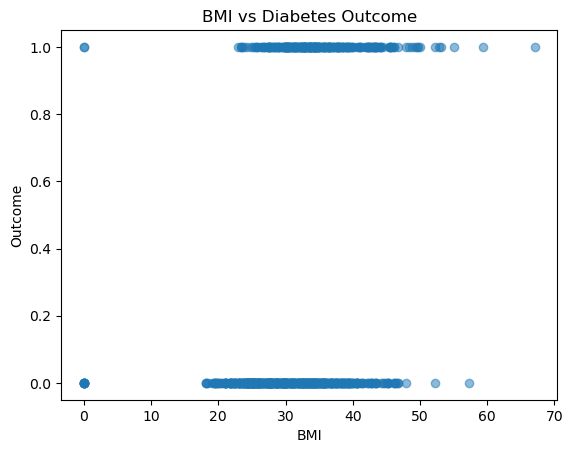

<Figure size 640x480 with 0 Axes>

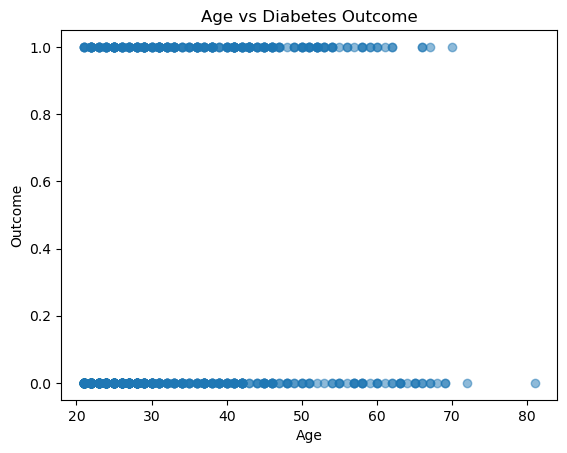

<Figure size 640x480 with 0 Axes>

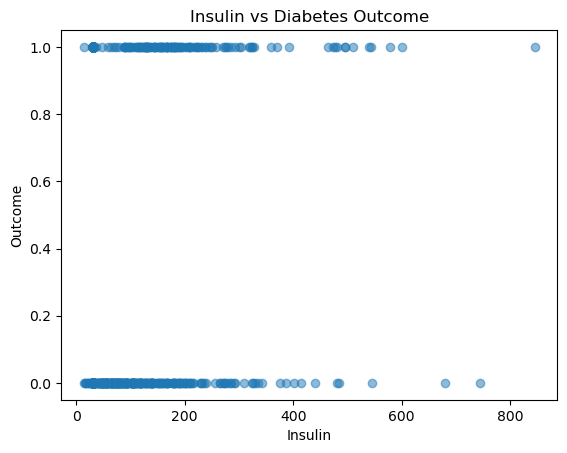

<Figure size 640x480 with 0 Axes>

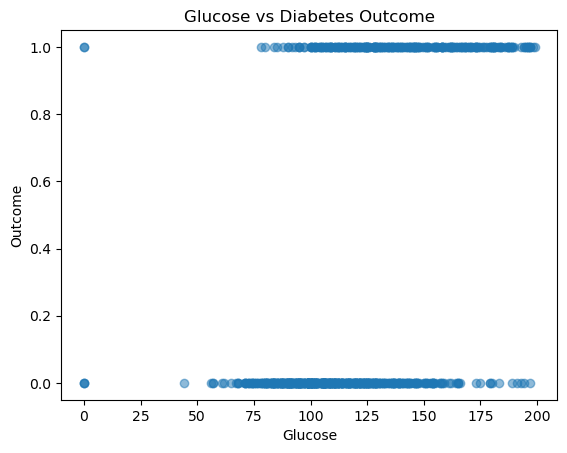

<Figure size 640x480 with 0 Axes>

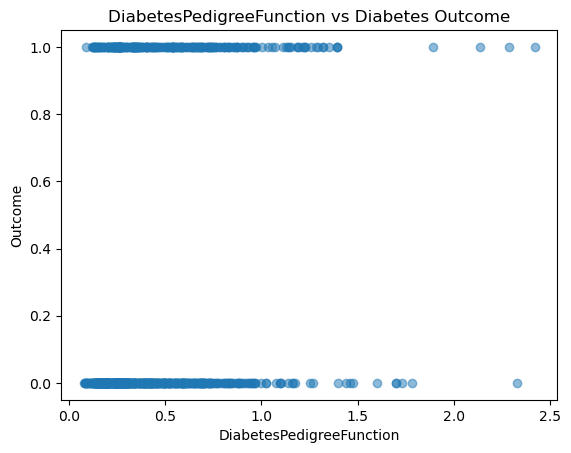

<Figure size 640x480 with 0 Axes>

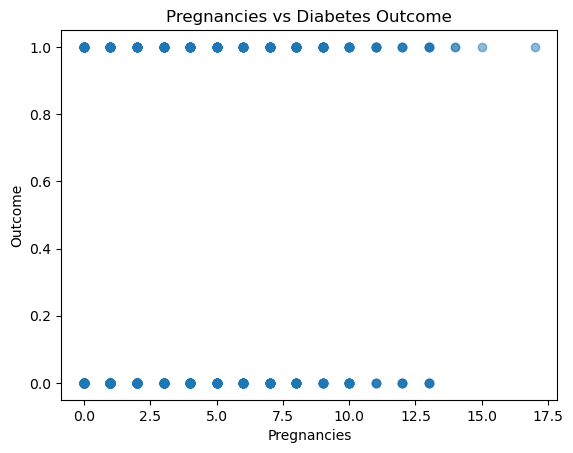

<Figure size 640x480 with 0 Axes>

In [13]:
#scatterplot
features = ["BMI", "Age", "Insulin","Glucose","DiabetesPedigreeFunction","Pregnancies"]

for col in features:
    
    plt.scatter(df[col], df["Outcome"], alpha=0.5)
    plt.xlabel(col)
    plt.ylabel("Outcome")
    plt.title(f"{col} vs Diabetes Outcome")
    plt.figure()
    plt.show()


C:\Users\nidam\AppData\Local\Temp\ipykernel_12072\1671802580.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(f"{col}_bin")["Outcome"].mean().plot(kind="bar")


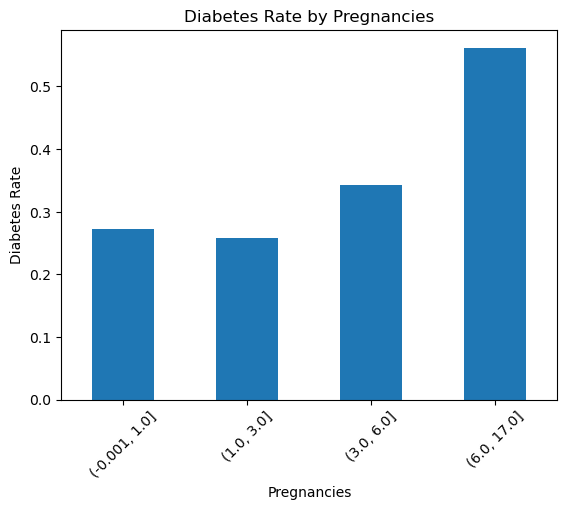

C:\Users\nidam\AppData\Local\Temp\ipykernel_12072\1671802580.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(f"{col}_bin")["Outcome"].mean().plot(kind="bar")


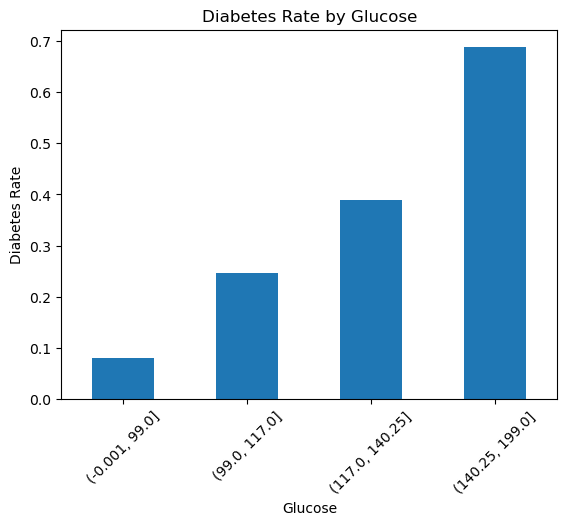

C:\Users\nidam\AppData\Local\Temp\ipykernel_12072\1671802580.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(f"{col}_bin")["Outcome"].mean().plot(kind="bar")


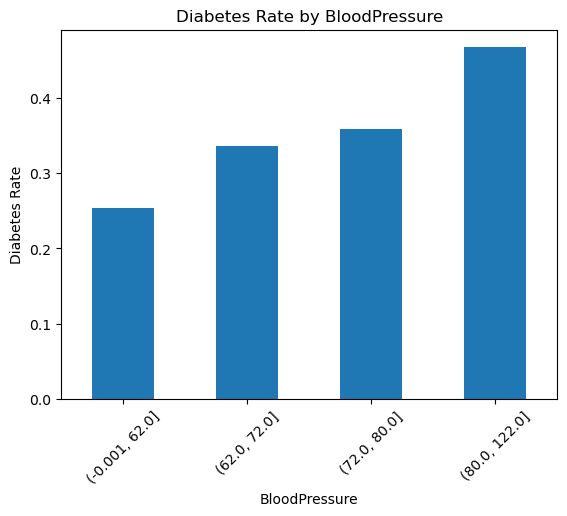

C:\Users\nidam\AppData\Local\Temp\ipykernel_12072\1671802580.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(f"{col}_bin")["Outcome"].mean().plot(kind="bar")


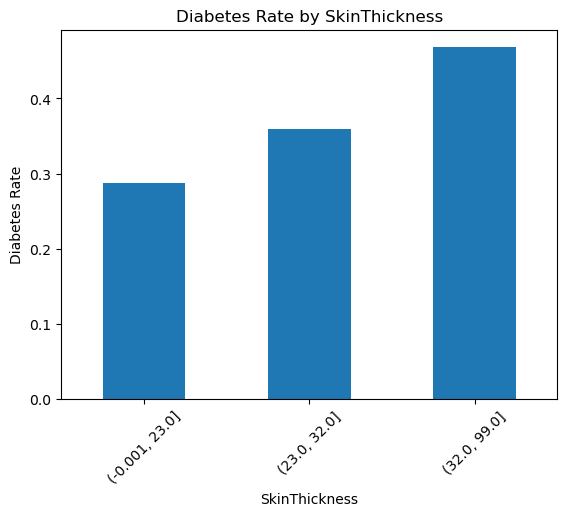

C:\Users\nidam\AppData\Local\Temp\ipykernel_12072\1671802580.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(f"{col}_bin")["Outcome"].mean().plot(kind="bar")


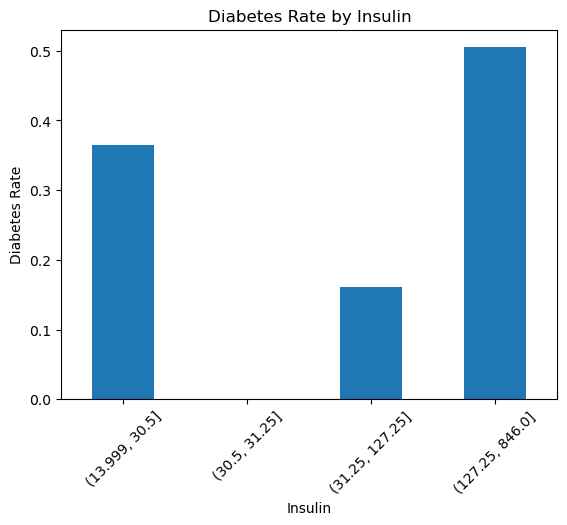

C:\Users\nidam\AppData\Local\Temp\ipykernel_12072\1671802580.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(f"{col}_bin")["Outcome"].mean().plot(kind="bar")


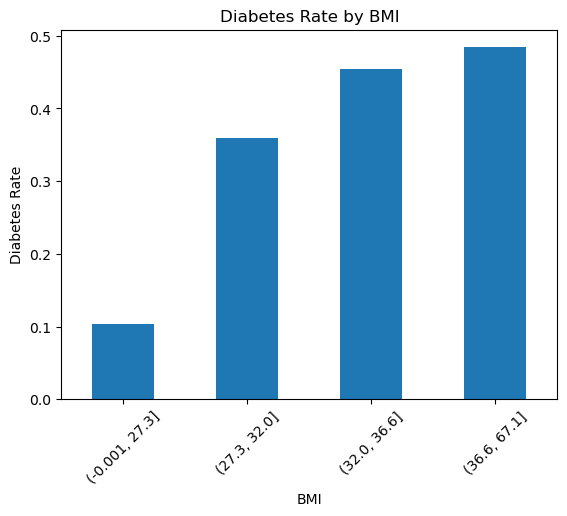

C:\Users\nidam\AppData\Local\Temp\ipykernel_12072\1671802580.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(f"{col}_bin")["Outcome"].mean().plot(kind="bar")


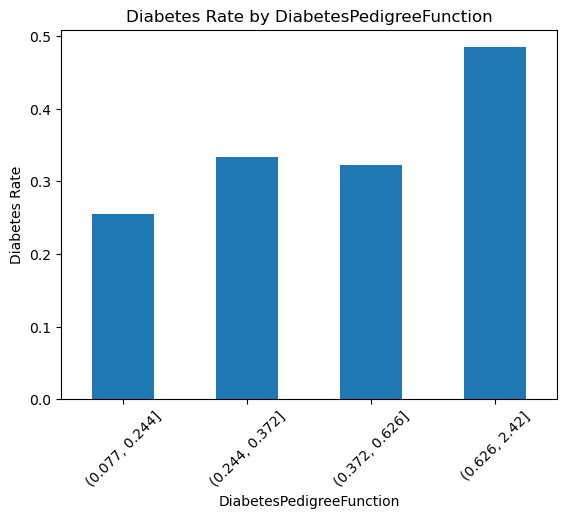

C:\Users\nidam\AppData\Local\Temp\ipykernel_12072\1671802580.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(f"{col}_bin")["Outcome"].mean().plot(kind="bar")


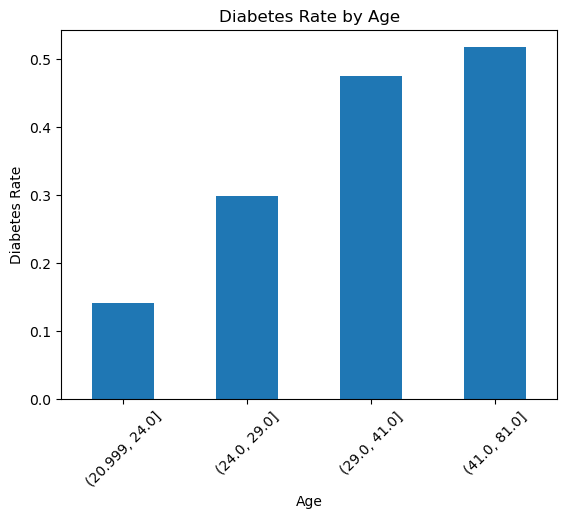

In [14]:
#bar charts
import pandas as pd
import matplotlib.pyplot as plt

features = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
]

for col in features:
    df[f"{col}_bin"] = pd.qcut(df[col], q=4, duplicates="drop")
    
    df.groupby(f"{col}_bin")["Outcome"].mean().plot(kind="bar")
    plt.ylabel("Diabetes Rate")
    plt.xlabel(col)
    plt.title(f"Diabetes Rate by {col}")
    plt.xticks(rotation=45)
    plt.show()


In [15]:
#there is no missing values but "0" is in the insuli i replace in median on that place
#there is no need encoding because no categorical columns
#no need to use preeprocees methods

In [25]:
x=df.iloc[:,[0,1,2,3,4,5,6,7]]
x.head()
y=df["Outcome"]

In [30]:
x_train,x_test,y_train,y_test= train_test_split(x,y,test_size=0.3)

In [46]:
xg= XGBClassifier(n_estimators=60,learning_rate=0.1,gamma=10,reg_lambda=4)
xg.fit(x_train,y_train)
y_train_pred=xg.predict(x_train)
y_test_pred=xg.predict(x_test)
#acc=accuracy_score(y_train,y_train_pred)
acct=accuracy_score(y_test,y_test_pred)
re=recall_score(y_test,y_test_pred)
pre=precision_score(y_test,y_test_pred)
f1=f1_score(y_test,y_test_pred)
print(f"accuracy:{acct:.2f}")
print(f"precision:{pre:.2f}")
print(f"recall:{re:.2f}")
print(f"f1_score:{f1:.2f}")
print("\n" + "="*50)
print("CROSS VALIDATION OF XGBOOST")
print("\n" + "="*50)
from sklearn.model_selection import ShuffleSplit, cross_validate
shuffle_split = ShuffleSplit(n_splits=200, test_size=0.3, random_state=42)
# Perform cross-validation and collect both train and test scores
cv_results = cross_validate(xg, x, y, cv=shuffle_split, scoring='accuracy', return_train_score=True)
# Extract train and test scores
train_scores = cv_results['train_score']
test_scores = cv_results['test_score']
# Show individual scores and their means
print("cross validation: test accuracy:" , np.round(train_scores.mean(),2))
print("cross validation: train accuracy:" , np.round(test_scores.mean(),2))

#========
print("\n" + "="*50)
print("GRIDSEARCHCV(HYPERPARAMETER TUNING) FOR XGBOOST")
print("\n" + "="*50)

from sklearn.model_selection import GridSearchCV
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1]
}
grid = GridSearchCV(
    XGBClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="f1"
)
grid.fit(x_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV F1 Score:", grid.best_score_)

accuracy:0.74
precision:0.68
recall:0.58
f1_score:0.62

CROSS VALIDATION OF XGBOOST

cross validation: test accuracy: 0.79
cross validation: train accuracy: 0.76

GRIDSEARCHCV(HYPERPARAMETER TUNING) FOR XGBOOST

Best Parameters: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100}
Best CV F1 Score: 0.6251619627675966


In [45]:
#lightgbm

lgbm= lgb.LGBMClassifier(n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    num_leaves=31,
    min_child_samples=30,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=100,
    verbose=-1)
lgbm.fit(x_train,y_train)
y_train_pred=lgbm.predict(x_train)
y_test_pred=lgbm.predict(x_test)
acct=accuracy_score(y_test,y_test_pred)
re=recall_score(y_test,y_test_pred)
pre=precision_score(y_test,y_test_pred)
f1=f1_score(y_test,y_test_pred)
print(f"accuracy:{acct:.2f}")
print(f"precision:{pre:.2f}")
print(f"recall:{re:.2f}")
print(f"f1_score:{f1:.2f}")

print("\n" + "="*50)
print("CROSS VALIDATION OF LIGHTGBBOOST")
print("\n" + "="*50)
from sklearn.model_selection import ShuffleSplit, cross_validate
shuffle_split = ShuffleSplit(n_splits=30, test_size=0.3, random_state=42)

# Perform cross-validation and collect both train and test scores
cv_results = cross_validate(lgbm, x, y, cv=shuffle_split, scoring='accuracy', return_train_score=True)

# Extract train and test scores
train_scores = cv_results['train_score']
test_scores = cv_results['test_score']

# Show individual scores and their means
print("cross validation: TRAIN ACCURACY:" , np.round(train_scores.mean(),2))
print("cross validation: TEST ACCURACY:" , np.round(test_scores.mean(),2))

print("\n" + "="*50)
print("GRIDSEARCHCV(HYPERPARAMETER TUNING) FOR LIGHTGBBOOST")
print("\n" + "="*50)
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1]
}

grid = GridSearchCV(
    LGBMClassifier(random_state=42, verbose=-1),
    param_grid,
    cv=5,
    scoring="f1"
)

grid.fit(x_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV F1 Score:", grid.best_score_)


accuracy:0.75
precision:0.68
recall:0.62
f1_score:0.65

CROSS VALIDATION OF LIGHTGBBOOST

cross validation: TRAIN ACCURACY: 0.89
cross validation: TEST ACCURACY: 0.75

GRIDSEARCHCV(HYPERPARAMETER TUNING) FOR LIGHTGBBOOST

Best Parameters: {'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 200}
Best CV F1 Score: 0.6154487038316132


In [ ]:
Comparison of LightGBM and XGBoost:

XGBoost achieved a test accuracy of 0.75, with precision 0.68, recall 0.62, and F1-score 0.65 after tuning.
LightGBM also achieved a test accuracy of 0.75, with the same precision (0.68), recall (0.62), and F1-score (0.65). 
This shows that both models perform similarly on the test dataset.

Generalization and overfitting analysis:
Cross-validation results show that XGBoost has a training accuracy of 0.79 and test accuracy of 0.76, indicating good generalization. 
    In contrast, LightGBM shows a higher training accuracy of 0.89 but a lower test accuracy of 0.75, which suggests overfitting.

Model reliability:
XGBoost achieved a higher cross-validated F1-score (0.625) compared to LightGBM (0.615), indicating a more balanced performance across classes. 
Although both models have similar accuracy, XGBoost is more stable across different data splits

Final conclusion:
Based on accuracy, recall, F1-score, and cross-validation results, XGBoost is slightly better than LightGBM for this dataset,
as it generalizes better and shows less overfitting while maintaining balanced performance.


